# HW9: Boosting and Neural Nets

## instructions

our course will be using an automatic grading system. <br>
after each question there will appear a code block with some prepared code to add your answer to a dictionary that will be sent to the course server for grading. <br>
please do not edit any code other than in placeholders marked `#### your code here ####` <br>
__don't forget to run the code block after you write your answer.__


you can add code blocks wherever you want in order to interact with datasets and play with your own code. <br>
in the next code block plase fill in your id number and email account in the appropriate placees. <br>
and __don't forget to run the block!__

In [1]:
ans = {}
ans['HW'] = 'HW9'
ans['id_number'] = 'ID_REMOVED'

#### Q1)
We described gradient boosting as taking the (negative) derivative of the loss after $t-1$ iterations and using that as the response for finding the weak learner in iteration $t.$ We than explained the use of residual as (half) the negative derivative of squared loss $L(y,\hat{y}) = (y-\hat{y})^2$. Using the notation from class, where $F^{(t-1)}$ is the model after $t-1$ iterations, we can denote this:
$$ y^{(t)}_i = y_i - F^{(t-1)}(x_i).$$

Now assume we instead do the following, for some $c>0$: 
$$ y^{(t)}_i = \left\{\begin{array}{ll} y_i - F^{(t-1)}(x_i) & \mbox{if } |y_i - F^{(t-1)}(x_i)|<c\\
c & \mbox{if } y_i - F^{(t-1)}(x_i) \geq c\\
-c  & \mbox{if } y_i - F^{(t-1)}(x_i) \leq -c. \end{array} \right.$$

What is a description of the loss function $L(y,\hat{y})$ that the resulting gradient boosting algorithm uses? 

1. It is quadratic when $|y-\hat{y}|<c$ and fixed when $|y-\hat{y}|\geq c$
2. It is absolute loss $L(y,\hat{y}) = |y-\hat{y}|$
3. It is quadratic when $|y-\hat{y}|<c$ and continues linearly when $|y-\hat{y}|\geq c$
4. There is no corresponding convex loss function

In [19]:
ans['Q1'] = 4

#### Q2)
Assume we build a Neural Network for regression as described in class, with one or more hidden layers, with one or more nodes in each hidden layer, and nonlinear transformation $\sigma$. For example, a model with two hidden layers, and two nodes in each, and $p$ explanatory variables, will be (as we showed in class): 
$$ f(x) = \sum_{i=1}^2 w_i^{(3)} \sigma \left(\sum_{j=1}^2 w^{(2)}_{ji} \sigma (\sum_{k=1}^p w^{(1)}_{kj} x_k)\right).$$
Assume that for the "nonlinearity" function $\sigma$ we decide to actually use the identity function $\sigma(u)=u.$
What can we say about the resulting model?

1. The model is linear in the covariates, i.e., $f(x) = \beta^t x$ for some $\beta$, and therefore we have gained nothing from the complex neural net
2. The resulting model will always be the identity $f(x)=x$, and therefore it is meaningless to use this function
3. The model we get can be a complex and non-linear function of $x$, because of the large number of weights in the network
4. The choice of $\sigma$ can be anything we want, including the zero function $\sigma(u)=0,\; \forall u$

In [3]:
ans['Q2'] = 3

#### Q3)
Assume we run an interative boosting algorithm, as described in class, but update the "residual" function $Y^{(t)}$ not every iteration, but every 10 iterations, for example if we use the actual residual we now get: 

1. Initialize $F^{(0)}(x) = 0\; \forall x,\;,Y^{(0)}=Y$
2. At stage $t \geq 1$:<br>    
    a. If $(t mod 10) == 0$ update $y_i^{(t)} = y_i - F^{(t-1)}(x_i),\;\forall i,$ otherwise set $y_i^{(t)} = y_i^{(t-1)},\;\forall i$ the previous value<br>
    b. Fit a weak learner $\hat{f}^{(t)}$ to $T^{(t)} = (X,Y^{(t)})$<br>
    c. Update $F^{(t)} = F^{(t-1)} + \epsilon \hat{f}^{(t)}$

What will this algorithm do after $T$ iterations? In particular, can we get the same model with an algorithm that updates the residual at every iteration? 

1. The same as building a model with $10$ times bigger data, with the same values of $\epsilon$ and $T$, and updating the residuals every iteration 
2. The same as building a model with $10 \epsilon$ (ten times bigger) for $T/10$ iterations, and updating the residuals every iteration
3. The same as building a model with $\epsilon/10$ (ten times smaller) for $10T$ iterations, and updating the residuals every iteration
4. There is no analogous approach that updates at every iteration



In [4]:
ans['Q3'] = 3

#### Q4)
Consider a very simple Neural network, applied to data with $p=2$ covariates, one hidden layer with one hidden unit with nonlinearity (activation) $\sigma(u) = 1/1(1+exp(-u))$, and no non-linearity in the output layer.<br>Note: This function has the nice derivative $\frac{\partial \sigma(u)}{\partial u} = \sigma(u) (1-\sigma(u)).$

This network has a total of $2+1$ weights. Assume we use the squared loss (RSS) to train the network. We have a current set of weights $W = (w^{(1)}_1, w^{(1)}_2, w^{(2)})$, and want to calculate the derivative $$\frac{\partial (y_i - \hat{y}_i)^2}{\partial w^{(1)}_1},$$ with 
$$ \hat{y}_i = w^{(2)}  \sigma (w^{(1)}_1 x_{i1} + w^{(1)}_2 x_{i2}).$$

Use the chain rule to find the correct expression for this derivative (denote $z = w^{(1)}_1 x_{i1} + w^{(1)}_2 x_{i2}$):
1. $-2 (y-\hat{y}_i) \sigma(z) (1-\sigma(z))$
2. $-2 (y-\hat{y}_i) w^{(2)} \sigma(z) (1-\sigma(z)) x_{i1}$
3. $ w^{(2)} \sigma(z) $
4. $ w^{(2)} \sigma(z) (1-\sigma(z)) + \sigma(z) (1-\sigma(z)) x_{i1}$


In [5]:
ans['Q4'] = 2

# CSD 5.5: boosting

0. For this Case Study assignment you should have in your current folder the ebay_boys_girls_shirts folder, holding the four CSV files describing the train and test shirts images, and the boys and girls images folders. This is what we did in CSD 1, **if you already have the data in your current folder you don't need to run this again!**:

In [6]:
import os
from pathlib import Path

dataset_root = Path(os.environ.get("SHIRTS_DATASET", "ebay_boys_girls_shirts")).expanduser().resolve()
if not (dataset_root / "boys_train.csv").is_file():
    raise FileNotFoundError("Set SHIRTS_DATASET to the extracted course image dataset directory")


1. In CSD4 we got the `x_train` and `x_test` matrices, and the `y_train` and `y_test` 0/1 vectors (0 = boys, 1 = girls).

    Complete the `get_final_matrices` function using all functions we've composed, to quickly get the four elements:

In [7]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform, color, img_as_ubyte

%matplotlib inline

def get_file_list(df, folder, n_sample = None, seed = None):
    if n_sample is None:
        file_ids_list = df.file_id.values
    else:
        file_ids_list = df.sample(n = n_sample, random_state = seed).file_id.values
    files_list = [folder + '/' + str(file_id) + '.jpg' for file_id in file_ids_list]
    return files_list

def read_image_and_resize(f, w = 100, h = 100):
    img = plt.imread(f)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        img = transform.resize(img, (w, h), mode='constant')
        img = img_as_ubyte(img)
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img = img[np.newaxis, :, :, :3]
    if img.shape != (1, 100, 100, 3):
        raise ValueError(f + str(img.shape))
    return img

def read_images_4d_array(files_list):
    images_list = [read_image_and_resize(file) for file in files_list]
    images_array = np.concatenate(images_list)
    return images_array

def get_images_matrix(csv_file, folder, n = None, seed = 1976):
    df = pd.read_csv(csv_file)
    files_list = get_file_list(df, folder, n, seed)
    images = read_images_4d_array(files_list)
    return images, files_list

def get_all_pixels(x):
    return x.reshape(-1, np.prod(x.shape[1:]))

def numpy_array_size_in_bytes(a):
    return a.size * a.itemsize

def shape_and_size(x, name):
    n_rows = x.shape[0]
    if len(x.shape) == 1:
        n_cols = 1
    elif len(x.shape) == 2:
        n_cols = x.shape[1]
    else:
        warnings.warn('Function is meaningful for 1 or 2-D numpy arrays, taking 2nd dimension as n_cols')
        n_cols = x.shape[1]        
    size = numpy_array_size_in_bytes(x)
    print('%s Shape: %d X %d, Size (bytes): %d' % (name, n_rows, n_cols, size))

def conf_matrix(y_true, y_pred):
    return pd.crosstab(y_true, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)

def get_final_matrices(n_train = None, n_test = None):
    folder = str(dataset_root) + '/' 
    x_boys_train, boys_train_files = get_images_matrix(folder + 'boys_train.csv', folder + 'boys', n_train)
    x_boys_test, boys_test_files = get_images_matrix(folder + 'boys_test.csv', folder + 'boys', n_test)
    x_girls_train, girls_train_files = get_images_matrix(folder + 'girls_train.csv', folder + 'girls', n_train)
    x_girls_test, girls_test_files = get_images_matrix(folder + 'girls_test.csv', folder + 'girls', n_test)
    
    x_boys_train_all = get_all_pixels(x_boys_train)
    x_boys_test_all = get_all_pixels(x_boys_test)
    x_girls_train_all = get_all_pixels(x_girls_train)
    x_girls_test_all = get_all_pixels(x_girls_test)

    x_train = np.vstack([x_boys_train_all, x_girls_train_all])
    x_test = np.vstack([x_boys_test_all, x_girls_test_all])

    y_boys_train = np.array([np.uint8(0)] * x_boys_train.shape[0])
    y_boys_test = np.array([np.uint8(0)] * x_boys_test.shape[0])
    y_girls_train = np.array([np.uint8(1)] * x_girls_train.shape[0])
    y_girls_test = np.array([np.uint8(1)] * x_girls_test.shape[0])
    y_train = np.concatenate([y_boys_train, y_girls_train])
    y_test = np.concatenate([y_boys_test, y_girls_test])
    
    return x_train, x_test, y_train, y_test

Upload 20% of the data:

In [8]:
x_train, x_test, y_train, y_test = get_final_matrices(n_train = 2000, n_test = 500)

Make sure you got what you wanted:

In [9]:
shape_and_size(x_train, 'x_train')
shape_and_size(x_test, 'x_test')
shape_and_size(y_train, 'y_train')
shape_and_size(y_test, 'y_test')

x_train Shape: 4000 X 30000, Size (bytes): 120000000
x_test Shape: 1000 X 30000, Size (bytes): 30000000
y_train Shape: 4000 X 1, Size (bytes): 4000
y_test Shape: 1000 X 1, Size (bytes): 1000


2. now let's try Gradient Boosted Trees with 100 trees. <br>
**this may take a while, If you're short on time try it with 10 trees at first** <br>
do not forget to use a random seed (random_state) of 0, this ensures reproducability of the results. 

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

mod = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state = 0)
mod.fit(x_train, y_train)

acc = mod.score(x_test, y_test)
ans['Q5'] = acc
print('Test accuracy on all pixels with GBT: %.3f' % acc)

y_pred = mod.predict(x_test)
y_test_s = np.array(['boys'] * len(y_test))
y_pred_s = np.array(['boys'] * len(y_test))
y_test_s[y_test == 1] = 'girls'
y_pred_s[y_pred == 1] = 'girls'
conf_matrix(y_test_s, y_pred_s)

Test accuracy on all pixels with GBT: 0.712


Predicted,boys,girl,All
True,,,
boys,333,167,500
girl,121,379,500
All,454,546,1000


3. as usual in classification problems, the final model depends on the threshold for classification. it is not always best to use the intuitive 0.5 threshold. <br>
plot the roc and report the auc of the model.

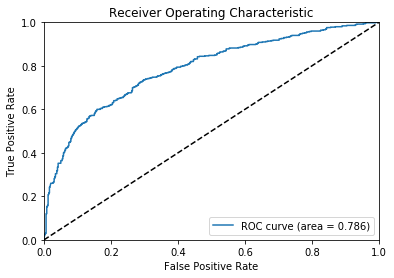

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_prob = mod.predict_proba(x_test)
y_pred_prob_1d = y_pred_prob[:, 0]

# Compute fpr, tpr, thresholds and roc auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_1d, pos_label=0)
roc_auc = roc_auc_score(1 - y_test, y_pred_prob_1d)
ans['Q6'] = roc_auc

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## neural network
as shown in the recitation create a simple fully connected neural network for classification.
use one hidden layer with 500 nodes and a "tanh" activation function.
train it for 50 epochs with a batch size of 100, use the binary cross entropy loss and adam solver as demonstrated in the recitation. <br>
remember the input layer size needs to be equal to the number of parameters, and you will want to use  an output layer of size 1 with a sigmoid activation function. 

In [21]:
from keras.models import Sequential
from keras.layers import Dense

from numpy.random import seed
seed(1)
from tensorflow.random import set_seed as set_random_seed
set_random_seed(2)

model = Sequential()
#model.add(Dense(30000, input_dim=30000, activation='tanh'))
model.add(Dense(500, input_dim=30000, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

predictions = model.predict(x_test)

model.summary()

model.fit(x_train, y_train, epochs=50, batch_size=100)

scores = model.evaluate(x_test, y_test)
print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_12 (Dense)             (None, 500)               15000500  
_________________________________________________________________
dense_13 (Dense)             (None, 1)                 501       
Total params: 15,001,001
Trainable params: 15,001,001
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
4000/4000 [==============================] - 13s 3ms/step - loss: 0.7883 - acc: 0.5185
Epoch 2/50
4000/4000 [==============================] - 12s 3ms/step - loss: 0.6949 - acc: 0.5090
Epoch 3/50
4000/4000 [==============================] - 13s 3ms/step - loss: 0.6900 - acc: 0.5330
Epoch 4/50
4000/4000 [==============================] - 15s 4ms/step - loss: 0.6890 - acc: 0.5250
Epoch 5/50
4000/4000 [==============================] - 12s 3ms/step - loss: 0.6930 - acc: 0.5175
Epoch 6/50
4000/4000 [==============

In [22]:
predictions = model.predict(x_test)

print(model.summary())

model.fit(x_train, y_train, epochs=50, batch_size=100)

scores = model.evaluate(x_test, y_test)
print(scores)
print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_12 (Dense)             (None, 500)               15000500  
_________________________________________________________________
dense_13 (Dense)             (None, 1)                 501       
Total params: 15,001,001
Trainable params: 15,001,001
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/50
4000/4000 [==============================] - 11s 3ms/step - loss: 0.6959 - acc: 0.4995
Epoch 2/50
4000/4000 [==============================] - 13s 3ms/step - loss: 0.6941 - acc: 0.4945
Epoch 3/50
4000/4000 [==============================] - 11s 3ms/step - loss: 0.6975 - acc: 0.4957
Epoch 4/50
4000/4000 [==============================] - 11s 3ms/step - loss: 0.6996 - acc: 0.4947
Epoch 5/50
4000/4000 [==============================] - 11s 3ms/step - loss: 0.7022 - acc: 0.5012
Epoch 6/50
4000/4000 [=========

In [23]:
print(scores)

[0.6940065326690674, 0.5]


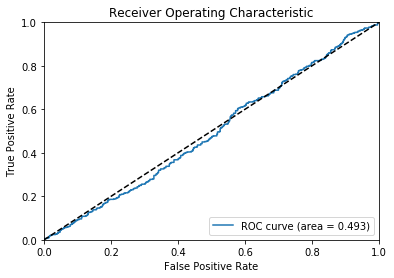

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, predictions, pos_label=0)
roc_auc2 = roc_auc_score(1 - y_test, predictions)

plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc2)
plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

report the following:

__Q7)__ how many weights does this network need to learn?<br>
__Q8)__ what is the AUC of this model?



In [25]:
ans['Q7'] = 15001001
ans['Q8'] = roc_auc2

## bonus

play with the neural network hyper-parameters (depth, # nodes, activation function, batch size, # epochs etc.)<br>
report your models AUC.<br>
you will get 5 points for beating the auc of the previous simple model<br>
and 5 extra points for the student with the best AUC in class.<br>
__do not__ change the random seed values.

In [26]:
from numpy.random import seed
seed(1)
from tensorflow.random import set_seed as set_random_seed
set_random_seed(2)


model = Sequential()
model.add(Dense(600, input_dim=30000, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='SGD', metrics=['accuracy'])

predictions = model.predict(x_test)

model.summary()

model.fit(x_train, y_train, epochs=20, batch_size=100)

scores = model.evaluate(x_test, y_test)
print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_14 (Dense)             (None, 600)               18000600  
_________________________________________________________________
dense_15 (Dense)             (None, 1)                 601       
Total params: 18,001,201
Trainable params: 18,001,201
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
4000/4000 [==============================] - 9s 2ms/step - loss: 0.7682 - acc: 0.5070
Epoch 2/20
4000/4000 [==============================] - 8s 2ms/step - loss: 0.7084 - acc: 0.5085
Epoch 3/20
4000/4000 [==============================] - 9s 2ms/step - loss: 0.7159 - acc: 0.5120
Epoch 4/20
4000/4000 [==============================] - 10s 2ms/step - loss: 0.7100 - acc: 0.5025
Epoch 5/20
4000/4000 [==============================] - 9s 2ms/step - loss: 0.7067 - acc: 0.5110
Epoch 6/20
4000/4000 [==================

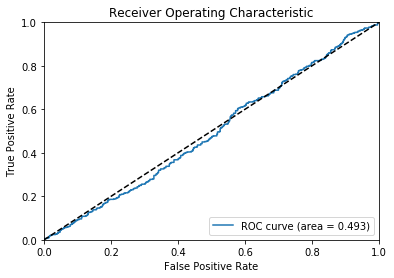

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, predictions, pos_label=0)
roc_auc3 = roc_auc_score(1 - y_test, predictions)

plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc3)
plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

report your best auc score, and describe the architecture of your model in free text (keep it short and informative, we will reporoduce your settings to validate the result)

In [30]:
ans['bonus'] = roc_auc3
ans['bonus_model'] = """model = Sequential()
model.add(Dense(600, input_dim=30000, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='SGD', metrics=['accuracy'])
"""

model = Sequential()
model.add(Dense(600, input_dim=30000, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='SGD', metrics=['accuracy'])



# finish!

to submit your HW please run this last code block and follow the instructions. <BR>
this code will create a CSV file in the current directory on the azure notebooks project <br>
please download it and submit it through moodle

In [31]:
import pandas as pd
df_ans = pd.DataFrame.from_dict(ans, orient='index')
if df_ans.shape[0] == 10 or df_ans.shape[0] == 12:
    df_ans.to_csv('{}_{}.csv'.format(ans['HW'],str(ans['id_number'])))
    print("OK!")
else:
    print("seems like you missed a question, make sure you have run all the code blocks")

OK!
